# Distances and means

In [3]:
import numpy as np
import random
from scipy.linalg import sqrtm, inv, logm, expm
from sklearn.neighbors import BallTree
import time

In [4]:
# ---------------------- distance functions ----------------------

def euclid_distance(a, b):
    d = a - b
    return float(np.sum(d * d))

def circle_distance(a, b):
    diff = np.abs(a - b)
    return float(np.sum(np.minimum(diff, 2 * np.pi - diff) ** 2))

def sphere_distance(a, b):
    dot = np.dot(a, b)
    dot = np.clip(dot, -1.0, 1.0)
    theta = np.arccos(dot)
    return float(theta * theta)

def grassmann_distance(X1, X2):
    U, S, Vt = np.linalg.svd(X1.T @ X2)
    angles = np.arccos(np.clip(S, -1, 1))
    return float(np.linalg.norm(angles))

def spd_affine_distance(A, B):
    sqrt_A = sqrtm(A)
    inv_sqrt_A = inv(sqrt_A)
    log_arg = inv_sqrt_A @ B @ inv_sqrt_A
    return float(np.linalg.norm(np.real(logm(log_arg)), 'fro'))

# ---------------------- mean functions --------------------------

def euclidean_mean(seg):
    return np.mean(seg, axis=0)

def circular_mean(seg):
    mean_angles = np.zeros(seg.shape[1])
    for j in range(seg.shape[1]):
        s, c = np.mean(np.sin(seg[:, j])), np.mean(np.cos(seg[:, j]))
        ang = np.arctan2(s, c)
        if ang < 0:
            ang += 2 * np.pi
        mean_angles[j] = ang
    return mean_angles   # <-- corrigé: le return était mal indenté

def spherical_mean(seg, max_iter=100, tol=1e-10):
    mu = np.mean(seg, axis=0)
    mu /= np.linalg.norm(mu)
    for _ in range(max_iter):
        grad = np.zeros_like(mu)
        for x in seg:
            dot = np.clip(np.dot(mu, x), -1.0, 1.0)
            theta = np.arccos(dot)
            if theta > tol:
                grad += theta / np.sin(theta) * (x - dot * mu)
        grad /= len(seg)
        if np.linalg.norm(grad) < tol:
            break
        normg = np.linalg.norm(grad)
        mu = np.cos(normg) * mu + np.sin(normg) * (grad / normg)
        mu /= np.linalg.norm(mu)
    return mu

def grassmann_mean(X_list, p=2, d=3, tol=1e-6, max_iter=100):
    M = X_list[0]
    for _ in range(max_iter):
        tangent_sum = np.zeros_like(M)
        for X in X_list:
            U, S, Vt = np.linalg.svd(M.T @ X)
            tangent = X - M @ (U @ Vt)
            tangent_sum += tangent
        tangent_norm = np.linalg.norm(tangent_sum)
        if tangent_norm < tol:
            break
        M += tangent_sum / len(X_list)
        U, _, Vt = np.linalg.svd(M, full_matrices=False)
        M = U @ Vt
    return M

def spd_frechet_mean(X_list, tol=1e-6, max_iter=50):
    M = X_list[0]
    for _ in range(max_iter):
        sum_log = np.zeros_like(M)
        sqrt_M = sqrtm(M)
        inv_sqrt_M = inv(sqrt_M)
        for X in X_list:
            log_arg = inv_sqrt_M @ X @ inv_sqrt_M
            sum_log += np.real(logm(log_arg))
        sum_log /= len(X_list)
        M_new = sqrt_M @ expm(sum_log) @ sqrt_M
        M_new = np.real(M_new)
        if np.linalg.norm(M_new - M) < tol:
            break
        M = M_new
    return M

# CATOP

In [6]:
# ---------------------- Initial centroids --------------------------

def init_mean(signal, frechet_mean, n_states):
    T = len(signal)
    centroids = [None] * n_states
    seg_size = T // n_states
    for i in range(n_states):
        start = i * seg_size
        end = T if i == n_states - 1 else (i + 1) * seg_size
        seg = signal[start:end]
        centroids[i] = frechet_mean(np.array(seg))
    return centroids

def init_pruning(signal, zeta, gamma, distance):
    X = np.asarray(signal)
    T = len(X)

    # Step 1: Compute local densities N(i)
        # Case: elements of X are 1-D
    if X.ndim == 2:
        tree = BallTree(X, metric=distance)
        neighbors = tree.query_radius(X, r=zeta)
        N = np.array([len(idx) for idx in neighbors])

        # Case: elements of X have dimension > 1 (brute force)
    else:
        N = np.array([np.sum([distance(xi, xj) <= zeta for xj in X])for xi in X])

    # Step 2: Keep only points with enough neighbors
    valid_idx = [i for i in range(T) if N[i] >= gamma]
    S = [X[i] for i in valid_idx]
    N_S = [N[i] for i in valid_idx]  # matching densities for S

    centroids = []

    # Step 3: Iterative selection and pruning
    while len(S) > 0:
        # pick the densest remaining point
        idx = int(np.argmax(N_S))
        X_tilde = S[idx]
        centroids.append(X_tilde)

        # remove all points too close to this centroid
        keep_mask = [distance(x, X_tilde) > 4 * zeta for x in S]
        S = [x for x, keep in zip(S, keep_mask) if keep]
        N_S = [n for n, keep in zip(N_S, keep_mask) if keep]

    return centroids


def init_mean_pruning(signal, zeta, gamma, distance, frechet_mean, n_states):
    pre_centroids = init_mean(signal, frechet_mean, n_states)
    centroids = init_pruning(pre_centroids, zeta, gamma, distance)
    return centroids

# ---------------------- Change point detection --------------------------

def CATOP(signal, distance, centroids, pen):
    T = len(signal)
    n_states = len(centroids)
    V = np.zeros((T + 1, n_states))
    tau = -np.ones((T + 1, n_states), dtype=int)
    path = -np.ones(T, dtype=int)

    best_prev = 0.0
    for t in range(1, T + 1):
        best_k = 0
        for k in range(n_states):
            V[t, k] = V[t - 1, k]
            tau[t, k] = tau[t - 1, k]
            if best_prev + pen < V[t - 1, k]:
                V[t, k] = best_prev + pen
                tau[t, k] = t - 2
            V[t, k] += distance(centroids[k], signal[t - 1]) ** 2
            if V[t, k] < V[t, best_k]:
                best_k = k
        best_prev = V[t, best_k]
        path[t - 1] = tau[t, best_k]

    chpnts = []
    s = path[-1]
    while s >= 0:
        chpnts.insert(0, s + 1)
        s = path[s]
    return chpnts


# Dubey-Muller

## Sphere

In [12]:
import numpy as np
from typing import List

# -----------------------------
# Exact Dubey-Muller statistic
# -----------------------------

def dm_stat_exact(data: List[np.ndarray], min_size: int = 10):
    """Compute renormalized T_n(u) for all candidate splits and return the best k."""
    n = len(data)

    # ---- Global Fréchet mean and variance ----
    mu_global = spherical_mean(data)
    d2 = np.array([sphere_distance(y, mu_global) for y in data])
    V_global = d2.mean()
    # Renormalization factor: variance of squared distances
    d4 = d2**2
    sigma_hat2 = d4.mean() - V_global**2

    best_stat = 0.0
    best_k = -1

    for k in range(min_size, n - min_size):
        u = k / n
        left = data[:k]
        right = data[k:]

        # Fréchet means
        mu_left = spherical_mean(left)
        mu_right = spherical_mean(right)

        # Cross variances
        V_left = np.mean([sphere_distance(y, mu_right) for y in left])
        V_right = np.mean([sphere_distance(y, mu_left) for y in right])

        # Centered variances
        VC_left = np.mean([sphere_distance(y, mu_left) for y in left])
        VC_right = np.mean([sphere_distance(y, mu_right) for y in right])

        # Raw Dubey-Müller statistic
        raw_stat = u * (1 - u) * (
            (V_left - V_right)**2
            + (VC_left - V_left + VC_right - V_right)**2
        )

        # ---- Renormalization by sigma_hat^2 ----
        stat = raw_stat / sigma_hat2

        if stat > best_stat:
            best_stat = stat
            best_k = k

    return best_k, best_stat

# -----------------------------
# Multi-change detection
# -----------------------------

def dm_multichange_sphere(data: List[np.ndarray], min_size: int = 20, threshold: float = 0.05, max_changes: int = 50):
    """Detect multiple change points using binary segmentation and exact T_n(u)."""
    n = len(data)
    detected = []
    segments = [(0, n)]

    while segments and len(detected) < max_changes:
        start, end = segments.pop()
        if end - start < 2 * min_size:
            continue

        segment_data = data[start:end]
        best_k_rel, best_stat = dm_stat_exact(segment_data, min_size)
        if best_k_rel == -1 or best_stat < threshold:
            continue

        best_k = start + best_k_rel
        detected.append(best_k)

        # Binary segmentation
        segments.append((start, best_k))
        segments.append((best_k, end))

    return sorted(detected)


## Grassmann

In [15]:
# -------------------------------------
# Exact Dubey–Müller statistic (Grassmann)
# -------------------------------------

def dm_stat_exact_grassmann(data: List[np.ndarray], min_size: int = 10):
    """Compute renormalized T_n(u) for all candidate splits on the Grassmannian."""
    n = len(data)

    # ---- Global Fréchet mean and variance ----
    mu_global = grassmann_mean(data)
    d2 = np.array([grassmann_distance(Y, mu_global) for Y in data])
    V_global = d2.mean()

    # Renormalization factor
    d4 = d2**2
    sigma_hat2 = d4.mean() - V_global**2
    if sigma_hat2 <= 0:
        sigma_hat2 = 1e-12  # safety

    best_stat = 0.0
    best_k = -1

    for k in range(min_size, n - min_size):
        u = k / n
        left = data[:k]
        right = data[k:]

        # Fréchet means
        mu_left = grassmann_mean(left)
        mu_right = grassmann_mean(right)

        # Cross variances
        V_left = np.mean([grassmann_distance(Y, mu_right) for Y in left])
        V_right = np.mean([grassmann_distance(Y, mu_left) for Y in right])

        # Centered variances
        VC_left = np.mean([grassmann_distance(Y, mu_left) for Y in left])
        VC_right = np.mean([grassmann_distance(Y, mu_right) for Y in right])

        # Raw Dubey–Müller statistic
        raw_stat = u * (1 - u) * (
            (V_left - V_right)**2
            + (VC_left - V_left + VC_right - V_right)**2
        )

        stat = raw_stat / sigma_hat2

        if stat > best_stat:
            best_stat = stat
            best_k = k

    return best_k, best_stat

def dm_multichange_grassmann(data: List[np.ndarray],
                             min_size: int = 20,
                             threshold: float = 0.05,
                             max_changes: int = 50):
    """Binary segmentation for multiple change-points on Grassmannian data."""
    n = len(data)
    detected = []
    segments = [(0, n)]

    while segments and len(detected) < max_changes:
        start, end = segments.pop()
        if end - start < 2 * min_size:
            continue

        segment = data[start:end]
        best_k_rel, best_stat = dm_stat_exact_grassmann(segment, min_size)

        if best_k_rel == -1 or best_stat < threshold:
            continue

        best_k = start + best_k_rel
        detected.append(best_k)

        # Binary segmentation
        segments.append((start, best_k))
        segments.append((best_k, end))

    return sorted(detected)



In [27]:
import numpy as np
from typing import List

# ------------------------------------------------------------
# Deterministic rotation to create a new subspace U2 from U1
# ------------------------------------------------------------
def rotate_subspace(U, theta):
    """
    Deterministically rotate the first basis vector of U by angle theta
    into a fixed orthogonal direction e1.
    """
    d, p = U.shape

    # Fixed direction e1
    e = np.zeros(d)
    e[0] = 1.0

    # Orthogonalize e against span(U)
    proj = U @ (U.T @ e)
    v = e - proj
    v = v / np.linalg.norm(v)

    # Apply rotation to first basis vector of U
    U2 = U.copy()
    U2[:, 0] = np.cos(theta) * U[:, 0] + np.sin(theta) * v

    # Re-orthonormalize
    Q, _ = np.linalg.qr(U2)
    return Q


# ------------------------------------------------------------
# Sample noisy Grassmann point around a deterministic subspace
# ------------------------------------------------------------
def grassmann_sample_around(U, noise=0.05):
    d, p = U.shape
    A = U + noise * np.random.randn(d, p)
    Q, _ = np.linalg.qr(A)
    return Q


# ------------------------------------------------------------
# Dummy Grassmann routines 
# ------------------------------------------------------------
def grassmann_mean(points: List[np.ndarray]) -> np.ndarray:
    M = sum(points) / len(points)
    Q, _ = np.linalg.qr(M)
    return Q

def grassmann_distance(A: np.ndarray, B: np.ndarray) -> float:
    U, s, Vt = np.linalg.svd(A.T @ B)
    s = np.clip(s, -1.0, 1.0)
    theta = np.arccos(s)
    return np.sum(theta**2)


# ------------------------------------------------------------
# Create synthetic dataset with a deterministic change at n//2
# ------------------------------------------------------------
n = 400
d = 4
p = 2

# Base subspace U1
U1, _ = np.linalg.qr(np.random.randn(d, p))

# Deterministic rotated subspace U2
theta = np.deg2rad(25)     # 25° rotation
U2 = rotate_subspace(U1, theta)

data = []
for i in range(n):
    if i < n // 2:
        data.append(grassmann_sample_around(U1, noise=0.05))
    else:
        data.append(grassmann_sample_around(U2, noise=0.05))


# ------------------------------------------------------------
# Multiple change-points using binary segmentation
# ------------------------------------------------------------
detected_cps = dm_multichange_grassmann(
    data,
    min_size=40,
    threshold=1,
    max_changes=10
)

print("Detected change-points:", detected_cps)


Detected change-points: [40, 90, 168, 208]


## SPD

In [17]:
def dm_stat_exact_spd(data, min_size=10):
    """Compute renormalized T_n(u) for all candidate splits on SPD matrices."""
    n = len(data)

    # ---- Global Fréchet mean and variance ----
    mu_global = spd_frechet_mean(data)
    d2 = np.array([spd_affine_distance(A, mu_global) for A in data])
    V_global = d2.mean()

    # Renormalization factor
    d4 = d2**2
    sigma_hat2 = d4.mean() - V_global**2
    if sigma_hat2 <= 0:
        sigma_hat2 = 1e-12  # safety

    best_stat = 0.0
    best_k = -1

    for k in range(min_size, n - min_size):
        u = k / n
        left = data[:k]
        right = data[k:]

        # Fréchet means
        mu_left = spd_frechet_mean(left)
        mu_right = spd_frechet_mean(right)

        # Cross variances
        V_left = np.mean([spd_affine_distance(A, mu_right) for A in left])
        V_right = np.mean([spd_affine_distance(A, mu_left) for A in right])

        # Centered variances
        VC_left = np.mean([spd_affine_distance(A, mu_left) for A in left])
        VC_right = np.mean([spd_affine_distance(A, mu_right) for A in right])

        # Raw Dubey–Müller statistic
        raw_stat = u * (1 - u) * (
            (V_left - V_right)**2 +
            (VC_left - V_left + VC_right - V_right)**2
        )

        stat = raw_stat / sigma_hat2

        if stat > best_stat:
            best_stat = stat
            best_k = k

    return best_k, best_stat

def dm_multichange_spd(data, min_size=20, threshold=0.05, max_changes=50):
    """Binary segmentation for multiple change-points on SPD-valued time series."""
    n = len(data)
    detected = []
    segments = [(0, n)]

    while segments and len(detected) < max_changes:
        start, end = segments.pop()
        if end - start < 2 * min_size:
            continue

        segment = data[start:end]
        best_k_rel, best_stat = dm_stat_exact_spd(segment, min_size)

        if best_k_rel == -1 or best_stat < threshold:
            continue

        best_k = start + best_k_rel
        detected.append(best_k)

        # Split segment
        segments.append((start, best_k))
        segments.append((best_k, end))

    return sorted(detected)



In [62]:
# --- Generate synthetic SPD time series with a change-point ---
np.random.seed(42)
n = 100  # number of matrices
dim = 3  # SPD dimension

# Generate SPD matrices around different means
def random_spd(dim):
    M = np.random.randn(dim, dim)
    return M @ M.T + dim * np.eye(dim)

# First 50 matrices around one mean
mean1 = random_spd(dim)
data1 = [mean1 + 0.1 * random_spd(dim) for _ in range(50)]

# Next 50 matrices around another mean
mean2 = random_spd(dim)
data2 = [mean2 + 0.1 * random_spd(dim) for _ in range(50)]

data = data1 + data2

# --- Multiple change-point detection ---
detected_cps = dm_multichange_spd(data, min_size=10, threshold=0.1)
print("Detected change-points:", detected_cps)

Detected change-points: [50]


# OCP-Rie

## Sphere

In [19]:
import time
import numpy as np
import torch
import pymanopt
from pymanopt.manifolds import Sphere
from pymanopt.optimizers.optimizer import Optimizer, OptimizerResult

# ============================================================
# 1. Stochastic Gradient Descent Optimizer
# ============================================================

class StochasticGradientDescent(Optimizer):
    """Riemannian stochastic gradient descent algorithm."""
    def __init__(self, step_size=None, num_iter=1, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._step_size = 1e-3 if step_size is None else step_size
        self._num_iter = num_iter

    def run(self, problem, *, initial_point=None) -> OptimizerResult:
        manifold = problem.manifold
        gradient = problem.riemannian_gradient

        if initial_point is None:
            x = manifold.random_point()
        else:
            x = initial_point

        start_time = time.time()

        for iteration in range(self._num_iter):
            grad = gradient(x)
            x = manifold.retraction(x, -self._step_size * grad)

        return self._return_result(
            start_time=start_time,
            point=x,
            cost=None,
            iterations=iteration,
            stopping_criterion=None,
            step_size=self._step_size,
        )

# ============================================================
# 2. Sphere cost function
# ============================================================

def sphere_cost(point, X_batch):
    # point: torch tensor on sphere
    # X_batch: torch tensor of shape (d,)
    ip = X_batch @ point
    return torch.sum(1.0 - ip)

# ============================================================
# 3. CPD on Sphere
# ============================================================

def riemannian_cpd_sphere(manifold, X_points, lambda_0, lambda_1, max_iter=1):
    """
    Compute CPD statistic point-by-point on the sphere.
    X_points: list of NumPy arrays of shape (d,)
    """
    opt0 = StochasticGradientDescent(step_size=lambda_0, num_iter=max_iter)
    opt1 = StochasticGradientDescent(step_size=lambda_1, num_iter=max_iter)

    theta0 = None
    theta1 = None
    stat = []

    for x in X_points:
        @pymanopt.function.pytorch(manifold)
        def cost(point):
            X_batch = torch.from_numpy(x).double()
            return sphere_cost(point, X_batch)

        problem = pymanopt.Problem(manifold, cost)

        if theta0 is None:
            init = x
            res0 = opt0.run(problem, initial_point=init)
            res1 = opt1.run(problem, initial_point=init)
        else:
            res0 = opt0.run(problem, initial_point=theta0)
            res1 = opt1.run(problem, initial_point=theta1)

        theta0 = res0.point
        theta1 = res1.point

        stat.append(manifold.dist(theta0, theta1))

    return stat

# ============================================================
# 4. Binary segmentation for multiple CPs on Sphere
# ============================================================

import numpy as np
from pymanopt.manifolds import Sphere

def OCP_Rie_Sphere(
        X_points,
        lambda_0,
        lambda_1,
        alpha=0.005,
        a=1.64,
        min_size=5,
        max_iter=1
):
    d = X_points[0].shape[0]
    manifold = Sphere(d)
    cps = []

    def process_segment(s, e):
        if e - s < 2 * min_size:
            return

        X_seg = X_points[s:e]
        stat_seg = riemannian_cpd_sphere(
            manifold=manifold,
            X_points=X_seg,
            lambda_0=lambda_0,
            lambda_1=lambda_1,
            max_iter=max_iter
        )
        if len(stat_seg) == 0:
            return

        mean = 0
        var = 0
        for s_val in stat_seg:
            mean = (1 - alpha) * mean + alpha * s_val
            var = (1 - alpha) * var + alpha * s_val**2
        sigma = np.sqrt(max(0, var - mean**2))
        threshold_seg = mean + a * sigma

        for k_local, val in enumerate(stat_seg):
            if val > threshold_seg:
                k_global = s + k_local
                if k_global - s < min_size or e - k_global < min_size:
                    return
                cps.append(k_global)
                process_segment(s, k_global)
                process_segment(k_global, e)
                break

    process_segment(0, len(X_points))
    return sorted(cps)




## Grassmann

In [20]:


# ============================================================
# 1. Riemannian Stochastic Gradient Descent
# ============================================================

class StochasticGradientDescent(Optimizer):
    """Riemannian stochastic gradient descent."""
    def __init__(self, step_size=None, num_iter=1, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._step_size = 1e-3 if step_size is None else step_size
        self._num_iter = num_iter

    def run(self, problem, *, initial_point=None):
        manifold = problem.manifold
        gradient = problem.riemannian_gradient

        if initial_point is None:
            x = manifold.random_point()
        else:
            x = initial_point

        start_time = time.time()
        for iteration in range(self._num_iter):
            grad = gradient(x)
            x = manifold.retraction(x, -self._step_size * grad)

        return type("OptimizerResult", (), {
            "point": x,
            "cost": None,
            "iterations": iteration
        })()

# ============================================================
# 2. Riemannian CPD (point-by-point) on Grassmann
# ============================================================

def riemannian_cpd_sphere_grassmann(manifold, X_points, lambda_0, lambda_1):
    optimizer0 = StochasticGradientDescent(step_size=lambda_0, num_iter=1)
    optimizer1 = StochasticGradientDescent(step_size=lambda_1, num_iter=1)
    
    stat = []
    result0 = result1 = None
    for matrix in X_points:
        @pymanopt.function.pytorch(manifold)
        def cost(point):
            temp1 = torch.from_numpy(matrix.T) @ point
            temp2 = torch.linalg.svd(temp1)[1]
            temp3 = torch.acos(torch.clamp(temp2, -1 + 1e-6, 1 - 1e-6))
            return torch.norm(temp3) ** 2

        problem = Problem(manifold, cost)
        if result0 is None:
            result0 = optimizer0.run(problem, initial_point=matrix)
            result1 = optimizer1.run(problem, initial_point=matrix)
        else:
            result0 = optimizer0.run(problem, initial_point=result0.point)
            result1 = optimizer1.run(problem, initial_point=result1.point)

        stat.append(manifold.dist(result0.point, result1.point))
    return stat

# ============================================================
# 3. Binary segmentation detection for multiple CPs on Grassmannian
# ============================================================

def OCP_Rie_grassmann(
        X_points,
        lambda_0,
        lambda_1,
        alpha=0.005,
        a=1.64,
        min_size=5,
        max_iter=1
):
    d, p = X_points[0].shape
    manifold = Grassmann(d, p)
    cps = []

    def process_segment(s, e):
        if e - s < 2 * min_size:
            return

        X_seg = X_points[s:e]
        stat_seg = riemannian_cpd_sphere_grassmann(
            manifold=manifold,
            X_points=X_seg,
            lambda_0=lambda_0,
            lambda_1=lambda_1
        )
        if len(stat_seg) == 0:
            return

        mean = 0.0
        var = 0.0
        for val in stat_seg:
            mean = (1 - alpha) * mean + alpha * val
            var = (1 - alpha) * var + alpha * val ** 2
        sigma = np.sqrt(max(0, var - mean ** 2))
        threshold_seg = mean + a * sigma

        for k_local, val in enumerate(stat_seg):
            if val > threshold_seg:
                k_global = s + k_local
                if k_global - s < min_size or e - k_global < min_size:
                    return
                cps.append(k_global)
                process_segment(s, k_global)
                process_segment(k_global, e)
                break

    process_segment(0, len(X_points))
    return sorted(cps)


In [146]:
import numpy as np
from typing import List

# ------------------------------------------------------------
# Deterministic rotation to create a new subspace U2 from U1
# ------------------------------------------------------------
def rotate_subspace(U, theta):
    d, p = U.shape
    e = np.zeros(d)
    e[0] = 1.0

    # Orthogonalize e against span(U)
    proj = U @ (U.T @ e)
    v = e - proj
    v = v / np.linalg.norm(v)

    # Apply rotation to first basis vector of U
    U2 = U.copy()
    U2[:, 0] = np.cos(theta) * U[:, 0] + np.sin(theta) * v

    Q, _ = np.linalg.qr(U2)
    return Q


# ------------------------------------------------------------
# Sample noisy Grassmann point around a deterministic subspace
# ------------------------------------------------------------
def grassmann_sample_around(U, noise=0.05):
    d, p = U.shape
    A = U + noise * np.random.randn(d, p)
    Q, _ = np.linalg.qr(A)
    return Q


# ------------------------------------------------------------
# --- Construct deterministic dataset with a true CP at n/2 ---
# ------------------------------------------------------------
n = 400
d = 4
p = 2

# Base subspace U1
U1, _ = np.linalg.qr(np.random.randn(d, p))

# Rotated subspace U2
theta = np.deg2rad(25)
U2 = rotate_subspace(U1, theta)

# Generate the dataset of Grassmann points
data = []
for i in range(n):
    if i < n // 2:
        data.append(grassmann_sample_around(U1, noise=0.05))
    else:
        data.append(grassmann_sample_around(U2, noise=0.05))


detected_cps = OCP_Rie_grassmann(
    X_points=data,
    lambda_0=0.01,
    lambda_1=0.02,
    alpha=0.005,     # slightly larger smoothing for stability
    a=1.,          # stronger threshold -> fewer false alarms
    min_size=40,    # consistent with your example
    max_iter=2      # improve convergence a bit
)

print("Detected change-points:", detected_cps)


Detected change-points: [209]


## SPD

In [23]:
import time
import numpy as np
import torch
import pymanopt
from pymanopt.manifolds import SymmetricPositiveDefinite
from pymanopt.optimizers.optimizer import Optimizer, OptimizerResult
from scipy.linalg import sqrtm, logm
# ============================================================
# 1. Stochastic Gradient Descent Optimizer (unchanged)
# ============================================================

class StochasticGradientDescent(Optimizer):
    """Riemannian stochastic gradient descent algorithm."""
    def __init__(self, step_size=None, num_iter=1, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._step_size = 1e-3 if step_size is None else step_size
        self._num_iter = num_iter

    def run(self, problem, *, initial_point=None) -> OptimizerResult:
        manifold = problem.manifold
        gradient = problem.riemannian_gradient

        if initial_point is None:
            x = manifold.random_point()
        else:
            x = initial_point

        start_time = time.time()

        for iteration in range(self._num_iter):
            grad = gradient(x)
            x = manifold.retraction(x, -self._step_size * grad)

        return self._return_result(
            start_time=start_time,
            point=x,
            cost=None,
            iterations=iteration,
            stopping_criterion=None,
            step_size=self._step_size,
        )

# ============================================================
# 2. SPD affine-invariant cost (squared distance)
# ============================================================

def spd_affine_cost(M, X):
    """
    Squared affine-invariant distance from M to X (all in PyTorch).
    M, X: torch tensors of shape (n, n)
    """
    # Compute matrix square root using torch.linalg
    sqrt_M = torch.linalg.cholesky(M)          # or torch.linalg.sqrtm if available
    inv_sqrt_M = torch.linalg.inv(sqrt_M)
    log_arg = inv_sqrt_M @ X @ inv_sqrt_M
    # Use torch.matrix_exp and logm approximation
    # For simplicity, approximate logm via eigen-decomposition:
    eigvals, eigvecs = torch.linalg.eigh(log_arg)
    log_mat = eigvecs @ torch.diag(torch.log(eigvals)) @ eigvecs.T
    cost_val = torch.norm(log_mat, 'fro')**2
    return cost_val

# ============================================================
# 3. General Riemannian CPD (point-by-point) for SPD
# ============================================================

def riemannian_cpd_spd(manifold, X_points, lambda_0, lambda_1):
    # optimizer
    optimizer0 = StochasticGradientDescent(step_size = lambda_0, num_iter = 1)
    optimizer1 = StochasticGradientDescent(step_size = lambda_1, num_iter = 1)
    # online CPD on Riemannian manifolds
    stat = []
    for matrix in X_points:
        @pymanopt.function.pytorch(manifold)
        def cost(point):
            temp1 = torch.linalg.eig(torch.from_numpy(matrix))
            temp2 = temp1[0].real
            c = temp1[1].real @ torch.diag(torch.sqrt(1/(torch.where(temp2 > 0, temp2, torch.tensor(1e-6, dtype=torch.float64))))) @ temp1[1].real.T
            temp3 = c @ point @ c
            temp4 = torch.linalg.eig(temp3)[0].real
            temp5 = torch.log(torch.where(temp4 > 0, temp4, torch.tensor(1e-6, dtype=torch.float64)))
            return torch.norm(temp5)**2
        problem = pymanopt.Problem(manifold, cost)
        if np.all(matrix == X_points[0]):
            result0 = optimizer0.run(problem, initial_point=matrix)
            result1 = optimizer1.run(problem, initial_point=matrix)
        else:
            result0 = optimizer0.run(problem, initial_point=result0.point)
            result1 = optimizer1.run(problem, initial_point=result1.point)
        stat.append(manifold.dist(result0.point, result1.point))
    return stat

# ============================================================
# 4. Binary segmentation for multiple CPs on SPD
# ============================================================

def OCP_Rie_SPD(
        X_points,
        lambda_0,
        lambda_1,
        alpha=0.005,
        a=1.64,
        min_size=5
):
    """
    Binary segmentation detection on SPD-valued points (list of n x n arrays).
    """
    n = X_points[0].shape[0]
    manifold = SymmetricPositiveDefinite(n)
    cps = []

    def process_segment(s, e):
        if e - s < 2 * min_size:
            return

        X_seg = X_points[s:e]
        stat_seg = riemannian_cpd_spd(
            manifold=manifold,
            X_points=X_seg,
            lambda_0=lambda_0,
            lambda_1=lambda_1
        )
        if len(stat_seg) == 0:
            return

        # adaptive mean/variance
        mean = 0.0
        var = 0.0
        for s_val in stat_seg:
            mean = (1 - alpha) * mean + alpha * s_val
            var = (1 - alpha) * var + alpha * (s_val ** 2)
        sigma = np.sqrt(max(0, var - mean ** 2))
        threshold_seg = mean + a * sigma

        for k_local, val in enumerate(stat_seg):
            if val > threshold_seg:
                k_global = s + k_local
                if k_global - s < min_size or e - k_global < min_size:
                    return
                cps.append(k_global)
                process_segment(s, k_global)
                process_segment(k_global, e)
                break

    process_segment(0, len(X_points))
    return sorted(cps)


In [295]:
import numpy as np
from scipy.linalg import sqrtm

# --- Helper to generate random SPD matrix ---
def random_spd(n):
    A = np.random.randn(n, n)
    return A @ A.T + n * np.eye(n)

# --- Generate synthetic SPD time series with a change-point ---
np.random.seed(42)
dim = 20
n_matrices = 30

# First segment around mean1
mean1 = random_spd(dim)
data1 = [mean1 + 0.05 * random_spd(dim) for _ in range(15)]

# Second segment around mean2
mean2 = random_spd(dim)
data2 = [mean2 + 0.05 * random_spd(dim) for _ in range(15)]

X_points = data1 + data2  # concatenated time series

# --- Run offline CPD detection ---
cps = OCP_Rie_SPD(
    X_points,
    lambda_0=0.01,
    lambda_1=0.02,
    alpha=0.01,
    a=1.64,
    min_size=6
)

print("Detected change-points at indices:", cps)


Detected change-points at indices: [20]


# Spherical data

In [41]:
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# -------------------------
# Simulation helpers
# -------------------------
def noisy_on_sphere(center, n, sigma=0.25, rng=None):
    rng = rng or np.random.default_rng()
    noise = rng.normal(scale=sigma, size=(n, 3))
    noise -= (noise @ center)[:, None] * center
    points = center + noise
    points /= np.linalg.norm(points, axis=1, keepdims=True)
    return points

def hausdorff_distance(A, B):
    A, B = np.asarray(A), np.asarray(B)
    if len(A) == 0 or len(B) == 0:
        return np.inf
    D = np.abs(A[:, None] - B[None, :])
    return max(np.max(np.min(D, axis=1)), np.max(np.min(D, axis=0)))

def generate_spherical_ts(n_changes, sigma, rng, T, n_states=3):
    centers = [np.array([1,0,0]), np.array([0,1,0]), np.array([0,0,1])]
    seg_lengths = [T // (n_changes + 1)] * (n_changes + 1)
    for j in range(T - sum(seg_lengths)):
        seg_lengths[j] += 1
    segments, true_cps = [], []
    pos = 0
    for j, L in enumerate(seg_lengths):
        seg = noisy_on_sphere(centers[j % n_states], L, sigma=sigma, rng=rng)
        segments.append(seg)
        if j > 0:
            true_cps.append(pos)
        pos += L
    return np.vstack(segments), np.array(true_cps)

# ----------------------------------------------------------
# full comparison with q repetitions
# ----------------------------------------------------------
def full_comparison(signal_generator, true_cps_generator, nb_mean, zeta, gamma_2, pen_1, pen_2, pen_3,
                    dm_threshold=0.05, dm_min_size=20, methods_to_run=None, q=5):

    methods = ["init_mean", "init_pruning", "init_mean_pruning", "Dubey-Muller", "Wang et al."]
    results = {m: {} for m in methods}

    rep_hausdorff = {m: [] for m in methods}
    rep_times = {m: [] for m in methods}
    rep_nb_changes = {m: [] for m in methods}

    for rep in range(q):
        signal = signal_generator(rep)
        true_cps = true_cps_generator(rep)

        for m in methods:
            if not methods_to_run.get(m, False):
                continue

            t0 = time.time()

            if m == "init_mean":
                centroids = init_mean(signal, spherical_mean, nb_mean)
                cps = CATOP(signal, sphere_distance, centroids, pen_1)

            elif m == "init_pruning":
                centroids = init_pruning(signal, zeta, gamma_2, sphere_distance)
                cps = CATOP(signal, sphere_distance, centroids, pen_2)

            elif m == "init_mean_pruning":
                centroids = init_mean_pruning(signal, zeta, gamma_2, sphere_distance,
                                              spherical_mean, nb_mean)
                cps = CATOP(signal, sphere_distance, centroids, pen_3)

            elif m == "Dubey-Muller":
                cps = dm_multichange_sphere(signal, min_size=30, threshold=dm_threshold)
                centroids = np.unique(signal, axis=0)

            elif m == "Wang et al.":
                cps = OCP_Rie_Sphere(
                    signal, lambda_0=0.02, lambda_1=0.01, alpha=0.005,
                    a=1.64, min_size=30, max_iter=1
                )
                centroids = np.unique(signal, axis=0)

            t1 = time.time() - t0

            rep_hausdorff[m].append(hausdorff_distance(cps, true_cps) / len(signal))
            rep_times[m].append(t1)
            rep_nb_changes[m].append(len(cps))

    # mean + std
    for m in methods:
        if not methods_to_run.get(m, False):
            results[m] = {k: np.nan for k in [
                "mean_error","std_error","mean_time","std_time",
                "mean_nb_change","std_nb_change"
            ]}
        else:
            results[m] = {
                "mean_error": np.mean(rep_hausdorff[m]),
                "std_error": np.std(rep_hausdorff[m]),
                "mean_time": np.mean(rep_times[m]),
                "std_time": np.std(rep_times[m]),
                "mean_nb_change": np.mean(rep_nb_changes[m]),
                "std_nb_change": np.std(rep_nb_changes[m]),
            }

    return results

# ----------------------------------------------------------
# main simulation function with error bars
# ----------------------------------------------------------
def run_simulation(list_T, nb_mean=30, sigma=0.5, n_changes=5,
                   zeta=0.2, gamma_2=5, q=5):

    methods = ["init_mean", "init_pruning", "init_mean_pruning", "Dubey-Muller", "Wang et al."]
    active_methods = {m: True for m in methods}

    mean_hausdorff = {m: [] for m in methods}
    std_hausdorff  = {m: [] for m in methods}

    mean_times = {m: [] for m in methods}
    std_times  = {m: [] for m in methods}

    mean_nb_changes = {m: [] for m in methods}
    std_nb_changes  = {m: [] for m in methods}

    for T in tqdm(list_T):
        pen_1 = pen_2 = pen_3 = T / 200

        def signal_gen(rep):
            rng = np.random.default_rng(seed=rep)
            signal, _ = generate_spherical_ts(n_changes, sigma, rng, T)
            return signal

        def true_cps_gen(rep):
            rng = np.random.default_rng(seed=rep)
            _, cps = generate_spherical_ts(n_changes, sigma, rng, T)
            return cps

        result = full_comparison(signal_gen, true_cps_gen,
                                 nb_mean, zeta, gamma_2,
                                 pen_1, pen_2, pen_3,
                                 dm_threshold=9.8/T,
                                 methods_to_run=active_methods, q=q)

        for m in methods:
            if active_methods[m]:
                mean_hausdorff[m].append(result[m]["mean_error"])
                std_hausdorff[m].append(result[m]["std_error"])

                mean_times[m].append(result[m]["mean_time"])
                std_times[m].append(result[m]["std_time"])

                mean_nb_changes[m].append(result[m]["mean_nb_change"])
                std_nb_changes[m].append(result[m]["std_nb_change"])

                if result[m]["mean_time"] > 300:
                    active_methods[m] = False
                    print(f" Stopping method {m} for T ≥ {T}")

            else:
                mean_hausdorff[m].append(np.nan)
                std_hausdorff[m].append(np.nan)
                mean_times[m].append(np.nan)
                std_times[m].append(np.nan)
                mean_nb_changes[m].append(np.nan)
                std_nb_changes[m].append(np.nan)

    # -------------------------
    # PLOT WITH ERROR BARS
    # -------------------------

    # Hausdorff
    plt.figure(figsize=(8,5))
    for m in methods:
        plt.errorbar(list_T, mean_hausdorff[m], yerr=std_hausdorff[m],
                     marker='o', capsize=4, label=m)
    plt.xlabel("T")
    plt.ylabel("Mean Hausdorff distance")
    plt.title("Change-point localization accuracy")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Time
    plt.figure(figsize=(8,5))
    for m in methods:
        plt.errorbar(list_T, mean_times[m], yerr=std_times[m],
                     marker='o', capsize=4, label=m)
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel("T (log-scale)")
    plt.ylabel("Computation time (s)")
    plt.title("Computation time vs T")
    plt.grid(True, which='both')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Number of changes
    plt.figure(figsize=(8,5))
    for m in methods:
        plt.errorbar(list_T, mean_nb_changes[m], yerr=std_nb_changes[m],
                     marker='o', capsize=4, label=m)
    plt.xlabel("T")
    plt.ylabel("Estimated number of changes")
    plt.title("Detected change-points")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mean_hausdorff, mean_times, mean_nb_changes


 33%|███▎      | 3/9 [2:16:36<5:14:35, 3145.94s/it]

 Stopping method Dubey-Muller for T ≥ 1200


100%|██████████| 9/9 [2:25:19<00:00, 968.85s/it]   


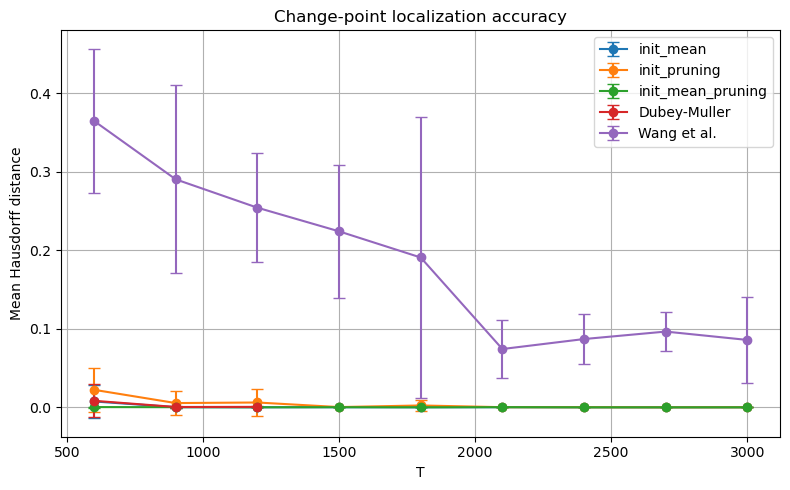

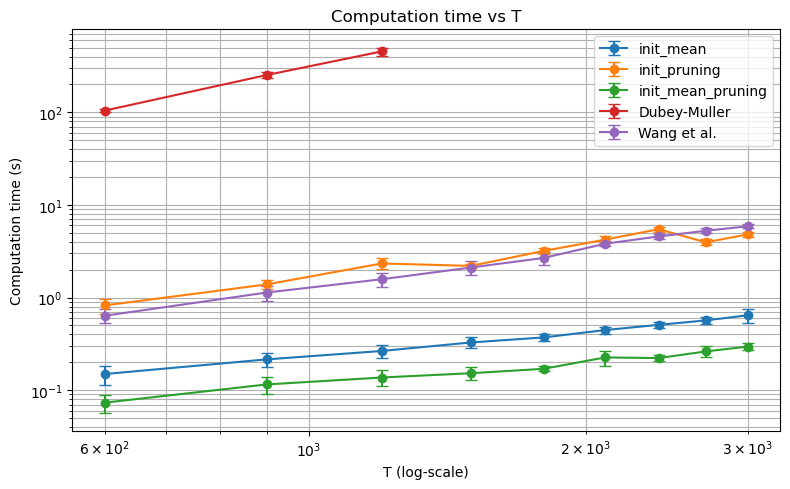

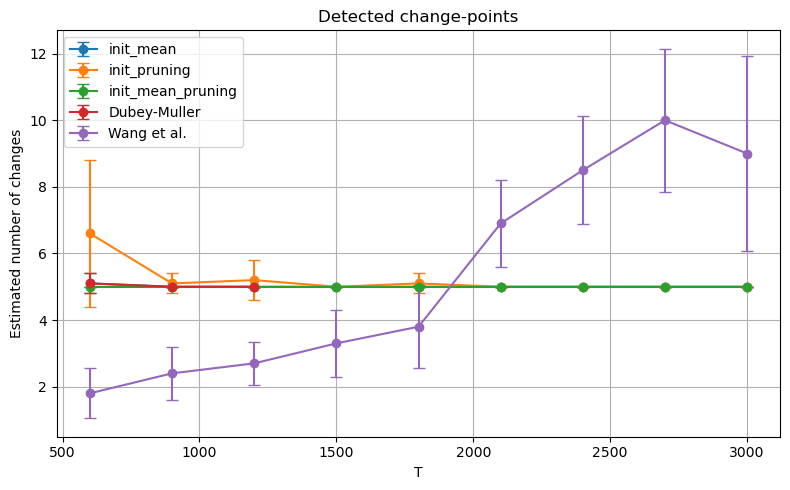

ValueError: not enough values to unpack (expected 4, got 3)

In [43]:
list_T = [600, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000]
mean_hausdorff, mean_times, mean_nb_changes = run_simulation(
    list_T=list_T,
    nb_mean=20,
    sigma=0.5,
    n_changes=5,
    zeta=0.2,
    gamma_2=1,
    q=10   # repetitions per T
)


# Grassmanian data

In [275]:
import numpy as np
import scipy.linalg 
import time

# --- Generate high-dimensional time series ---
def generate_high_dim_ts_with_cps(
    d=10, K=6, n_per_segment=50,
    d_cube=2, cube_size=1.0,
    noise_std=0.05, seed=None
):
    if seed is not None:
        np.random.seed(seed)

    X = []
    true_cps = []
    pos = 0

    # --- Define 2 states that share (d_cube-1) axes ---
    # Shared axes
    shared_axes = np.arange(d_cube - 1)

    # State 0: shared axes + a special axis p
    # State 1: shared axes + a different special axis q
    p = d_cube - 1
    q = d_cube         # only one axis differs between the states

    state_axes = [
        np.concatenate([shared_axes, [p]]),  # state 0
        np.concatenate([shared_axes, [q]])   # state 1
    ]

    # Modulo in case d < axes
    state_axes = [axes % d for axes in state_axes]

    for k in range(K):
        segment = np.zeros((n_per_segment, d))

        # Alternate between the two states: 0,1,0,1,0,1,...
        state = k % 2
        axes = state_axes[state]

        # Uniform cube in the latent d_cube-dimensions
        u = np.random.uniform(-cube_size/2, cube_size/2,
                              size=(n_per_segment, d_cube))
        
        # Embed into ambient space
        segment[:, axes] = u

        # Add ambient isotropic noise
        segment += np.random.normal(scale=noise_std,
                                    size=(n_per_segment, d))

        X.append(segment)

    return np.vstack(X)


# --- Transform to Grassmannian ---
def time_series_to_grassmannian_fixed_grid(X, segment_length=20, subspace_dim=2):
    n_segments = X.shape[0] // segment_length
    subspaces = []
    
    for i in range(n_segments):
        segment = X[i*segment_length : (i+1)*segment_length]
        segment -= segment.mean(axis=0)
        _, _, Vt = scipy.linalg.svd(segment, full_matrices=False)
        basis = Vt[:subspace_dim].T
        subspaces.append(basis)
    
    return subspaces

import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------
def hausdorff_distance(A, B):
    A, B = np.asarray(A), np.asarray(B)
    if len(A) == 0 or len(B) == 0:
        return np.inf
    D = np.abs(A[:, None] - B[None, :])
    return max(np.max(np.min(D, axis=1)), np.max(np.min(D, axis=0)))

# ----------------------------------------------------------
# Full comparison for Grassmannian-valued time series
# ----------------------------------------------------------
def full_comparison_grassmann(
        signal_generator, true_cps, segment_length,
        nb_mean=5, zeta=0.1, gamma_2=4,
        pen_1=1.0, pen_2=1.0, pen_3=1.0,
        lambda_0=0.01, lambda_1=0.02,
        alpha=0.01, a=1.64,
        dm_min_size=40, dm_threshold=1.0,
        dm_max_changes=10,
        methods_to_run=None, q=5
):
    methods = ["init_mean", "init_pruning", "init_mean_pruning",
               "Wang et al.", "Dubey-Muller"]
    results = {m: {} for m in methods}

    rep_hausdorff = {m: [] for m in methods}
    rep_times = {m: [] for m in methods}
    rep_nb_changes = {m: [] for m in methods}

    for rep in range(q):
        subspaces = signal_generator(rep)

        for m in methods:
            if not methods_to_run.get(m, False):
                continue

            t0 = time.time()

            if m == "init_mean":
                centroids = init_mean(subspaces, grassmann_mean, nb_mean)
                cps = CATOP(subspaces, grassmann_distance, centroids, pen_1)

            elif m == "init_pruning":
                centroids = init_pruning(subspaces, zeta, gamma_2, grassmann_distance)
                cps = CATOP(subspaces, grassmann_distance, centroids, pen_2)

            elif m == "init_mean_pruning":
                centroids = init_mean_pruning(
                    subspaces, zeta, gamma_2,
                    grassmann_distance, grassmann_mean, nb_mean
                )
                cps = CATOP(subspaces, grassmann_distance, centroids, pen_3)

            elif m == "Wang et al.":
                cps = OCP_Rie_grassmann(
                    X_points=subspaces,
                    lambda_0=lambda_0,
                    lambda_1=lambda_1,
                    alpha=alpha,
                    a=a,
                    min_size=20,
                    max_iter=1
                )
                centroids = subspaces  # not used

            elif m == "Dubey-Muller":
                cps = dm_multichange_grassmann(
                    subspaces,
                    min_size=dm_min_size,
                    threshold=dm_threshold,
                    max_changes=4
                )
                centroids = subspaces  # not used

            t1 = time.time() - t0
            rep_hausdorff[m].append(hausdorff_distance(np.array(cps)*segment_length, true_cps) / (len(subspaces)*segment_length))
            rep_times[m].append(t1)
            rep_nb_changes[m].append(len(cps))

    # Compute mean and std
    for m in methods:
        if not methods_to_run.get(m, False):
            results[m] = {k: np.nan for k in [
                "mean_error","std_error","mean_time","std_time",
                "mean_nb_change","std_nb_change"
            ]}
        else:
            results[m] = {
                "mean_error": np.mean(rep_hausdorff[m]),
                "std_error": np.std(rep_hausdorff[m]),
                "mean_time": np.mean(rep_times[m]),
                "std_time": np.std(rep_times[m]),
                "mean_nb_change": np.mean(rep_nb_changes[m]),
                "std_nb_change": np.std(rep_nb_changes[m]),
            }

    return results

# ----------------------------------------------------------
# Main simulation loop with error bars
# ----------------------------------------------------------
def run_simulation_grassmann_vary_n_per_segment(list_n_per_segment, segment_length=20, subspace_dim=2,
                                                d=10, K=6, d_cube=2, nb_mean=5, noise_std=0.05,
                                                zeta=0.1, gamma_2=4, q=5):

    methods = ["init_mean", "init_pruning", "init_mean_pruning",
               "Wang et al.", "Dubey-Muller"]
    active_methods = {m: True for m in methods}

    mean_hausdorff = {m: [] for m in methods}
    std_hausdorff  = {m: [] for m in methods}
    mean_times = {m: [] for m in methods}
    std_times  = {m: [] for m in methods}
    mean_nb_changes = {m: [] for m in methods}
    std_nb_changes  = {m: [] for m in methods}

    for n_per_segment in tqdm(list_n_per_segment):
        pen_1 = pen_2 = pen_3 = n_per_segment / 1000 
        dm_threshold=segment_length*9.8/(K*n_per_segment)

        def signal_gen(rep):
            X = generate_high_dim_ts_with_cps(d=d, K=K, n_per_segment=n_per_segment,d_cube=d_cube, noise_std=noise_std, seed=rep)
            subspaces = time_series_to_grassmannian_fixed_grid(X, segment_length=segment_length, subspace_dim=subspace_dim)
            return subspaces

        true_cps = [k * n_per_segment for k in range(1, K)]

        result = full_comparison_grassmann(
            signal_gen, true_cps, segment_length,
            nb_mean=nb_mean, zeta=zeta, gamma_2=gamma_2,
            pen_1=pen_1, pen_2=pen_2, pen_3=pen_3, dm_threshold=dm_threshold,
            methods_to_run=active_methods, q=q
        )

        for m in methods:
            if active_methods[m]:
                mean_hausdorff[m].append(result[m]["mean_error"])
                std_hausdorff[m].append(result[m]["std_error"])
                mean_times[m].append(result[m]["mean_time"])
                std_times[m].append(result[m]["std_time"])
                mean_nb_changes[m].append(result[m]["mean_nb_change"])
                std_nb_changes[m].append(result[m]["std_nb_change"])

                if result[m]["mean_time"] > 300:
                    active_methods[m] = False
                    print(f" Stopping method {m} for n_per_segment ≥ {n_per_segment}")
            else:
                mean_hausdorff[m].append(np.nan)
                std_hausdorff[m].append(np.nan)
                mean_times[m].append(np.nan)
                std_times[m].append(np.nan)
                mean_nb_changes[m].append(np.nan)
                std_nb_changes[m].append(np.nan)

    # Plotting (same as before)
    # Hausdorff
    plt.figure(figsize=(8,5))
    for m in methods:
        plt.errorbar(list_n_per_segment, mean_hausdorff[m], yerr=std_hausdorff[m],
                     marker='o', capsize=4, label=m)
    plt.xlabel("n_per_segment")
    plt.ylabel("Mean Hausdorff distance")
    plt.title("Change-point localization accuracy (Grassmann)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Computation time
    plt.figure(figsize=(8,5))
    for m in methods:
        plt.errorbar(list_n_per_segment, mean_times[m], yerr=std_times[m],
                     marker='o', capsize=4, label=m)
    plt.xscale('log'); plt.yscale('log')
    plt.xlabel("n_per_segment (log-scale)")
    plt.ylabel("Computation time (s)")
    plt.title("Computation time vs n_per_segment")
    plt.grid(True, which='both')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Number of changes
    plt.figure(figsize=(8,5))
    for m in methods:
        plt.errorbar(list_n_per_segment, mean_nb_changes[m], yerr=std_nb_changes[m],
                     marker='o', capsize=4, label=m)
    plt.xlabel("n_per_segment")
    plt.ylabel("Estimated number of changes")
    plt.title("Detected change-points (Grassmann)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mean_hausdorff, mean_times, mean_nb_changes



100%|██████████| 11/11 [22:43<00:00, 123.98s/it]


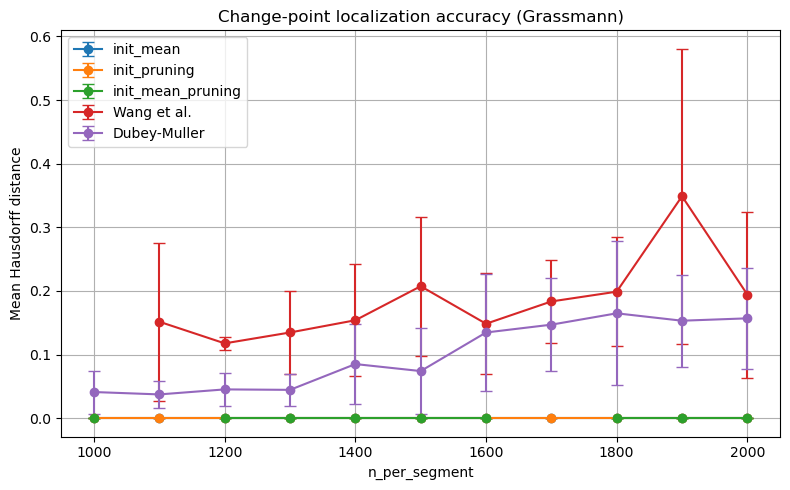

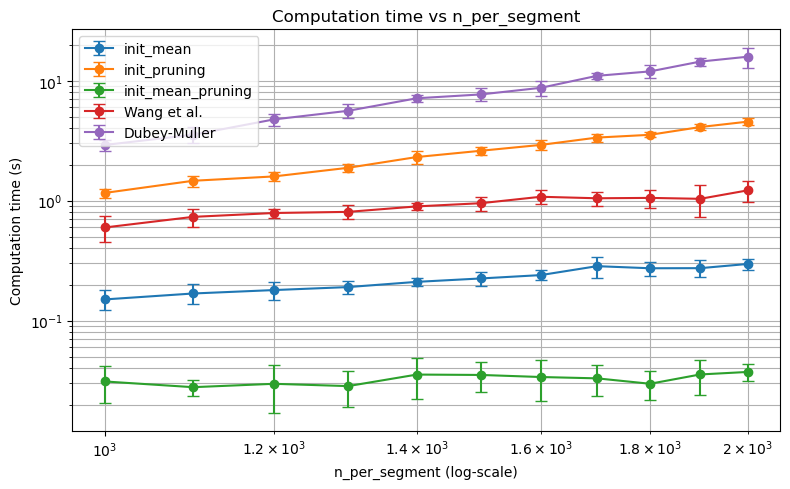

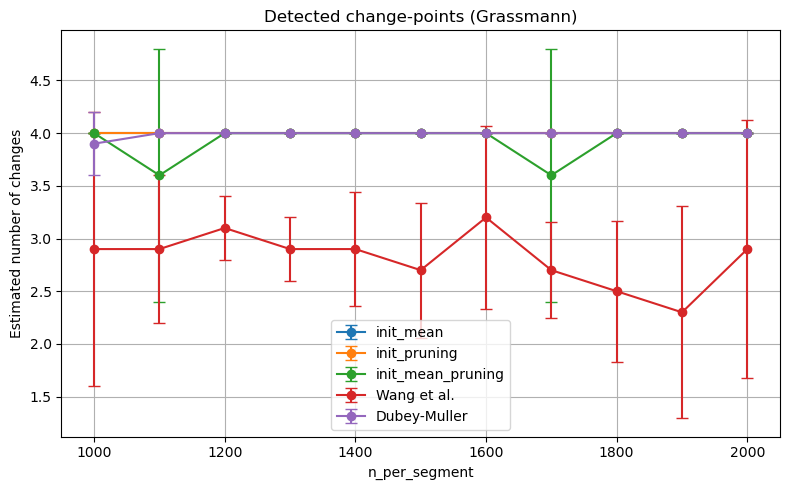

In [277]:
list_n_per_segment = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]

# Run the Grassmannian simulation
mean_hausdorff, mean_times, mean_nb_changes = run_simulation_grassmann_vary_n_per_segment(
    list_n_per_segment=list_n_per_segment,
    segment_length=20,   # segment length for subspaces
    subspace_dim=2,      # dimension of Grassmann subspaces
    d=5,                # ambient dimension
    K=5,                 # number of alternating latent states
    d_cube=2,            # latent cube dimension
    nb_mean=30,           # for init_mean methods
    noise_std=0.05,      # noise in time series
    zeta=0.1,
    gamma_2=4,
    q=10                  # number of repetitions per n_per_segment
)

# Graph time series

In [25]:
import numpy as np
import networkx as nx

def generate_sbm_graph_ts(T, n_nodes=20, n_blocks=2,
                          p_list=[0.8, 0.2], q_list=[0.2, 0.8],
                          n_changes=5, epsilon=1e-3, rng=None):
    """
    Generate a time series of SPD matrices from graphs via SBM.

    Returns
    -------
    segments : np.ndarray of shape (T, n_nodes, n_nodes)
        SPD matrices for the graph time series.
    true_cps : np.ndarray
        Indices of the change points.
    """
    rng = rng or np.random.default_rng()
    seg_lengths = [T // (n_changes + 1)] * (n_changes + 1)
    for j in range(T - sum(seg_lengths)):
        seg_lengths[j] += 1

    segments = []
    true_cps = []
    pos = 0

    for j, L_seg in enumerate(seg_lengths):
        # Alternate states 0 and 1
        state = j % 2
        p_intra = p_list[state]
        q_inter = q_list[state]

        # Define SBM block sizes
        sizes = [n_nodes // n_blocks] * n_blocks
        if sum(sizes) < n_nodes:
            sizes[-1] += n_nodes - sum(sizes)

        # Probability matrix
        probs = np.full((n_blocks, n_blocks), q_inter)
        np.fill_diagonal(probs, p_intra)

        # Generate SBM graph with a proper Python int seed
        seed_val = int(rng.integers(0, 1e6))
        G = nx.stochastic_block_model(sizes, probs, seed=seed_val)

        # Laplacian + epsilon*I for SPD
        L = nx.laplacian_matrix(G).toarray()
        L_spd = L + epsilon * np.eye(n_nodes)

        # Repeat for the segment length
        for _ in range(L_seg):
            segments.append(L_spd)

        if j > 0:
            true_cps.append(pos)
        pos += L_seg

    return np.array(segments), np.array(true_cps)


In [27]:
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

# -------------------------
# Hausdorff distance helper
# -------------------------
def hausdorff_distance(A, B):
    A, B = np.asarray(A), np.asarray(B)
    if len(A) == 0 or len(B) == 0:
        return np.inf
    D = np.abs(A[:, None] - B[None, :])
    return max(np.max(np.min(D, axis=1)), np.max(np.min(D, axis=0)))

# -------------------------
# Full comparison function
# -------------------------
def full_comparison_graphs(signal_generator, true_cps_generator,
                           nb_mean, zeta, gamma_2, pen_1, pen_2, pen_3,
                           dm_threshold=0.05, dm_min_size=20,
                           methods_to_run=None, q=5):
    
    methods = ["init_mean", "init_pruning", "init_mean_pruning", "Dubey-Muller", "Wang et al."]
    results = {m: {} for m in methods}
    
    rep_hausdorff = {m: [] for m in methods}
    rep_times = {m: [] for m in methods}
    rep_nb_changes = {m: [] for m in methods}

    for rep in range(q):
        signal = signal_generator(rep)
        true_cps = true_cps_generator(rep)

        for m in methods:
            if not methods_to_run.get(m, False):
                continue

            t0 = time.time()

            if m == "init_mean":
                centroids = init_mean(signal, spd_frechet_mean, nb_mean)
                cps = CATOP(signal, spd_affine_distance, centroids, pen_1)

            elif m == "init_pruning":
                centroids = init_pruning(signal, zeta, gamma_2, spd_affine_distance)
                cps = CATOP(signal, spd_affine_distance, centroids, pen_2)

            elif m == "init_mean_pruning":
                centroids = init_mean_pruning(signal, zeta, gamma_2, spd_affine_distance,
                                              spd_frechet_mean, nb_mean)
                cps = CATOP(signal, spd_affine_distance, centroids, pen_3)

            elif m == "Wang et al.":
                cps = OCP_Rie_SPD(signal,
                                             lambda_0=0.02,
                                             lambda_1=0.01,
                                             alpha=0.005,
                                             a=1.64,
                                             min_size=dm_min_size)
                centroids = np.unique(signal, axis=0)

            elif m == "Dubey-Muller":
                cps = dm_multichange_spd(signal, min_size=dm_min_size, threshold=dm_threshold)
                centroids = np.unique(signal, axis=0)

            t1 = time.time() - t0

            rep_hausdorff[m].append(hausdorff_distance(cps, true_cps) / len(signal))
            rep_times[m].append(t1)
            rep_nb_changes[m].append(len(cps))

    # mean + std
    for m in methods:
        if not methods_to_run.get(m, False):
            results[m] = {k: np.nan for k in [
                "mean_error","std_error","mean_time","std_time",
                "mean_nb_change","std_nb_change"
            ]}
        else:
            results[m] = {
                "mean_error": np.mean(rep_hausdorff[m]),
                "std_error": np.std(rep_hausdorff[m]),
                "mean_time": np.mean(rep_times[m]),
                "std_time": np.std(rep_times[m]),
                "mean_nb_change": np.mean(rep_nb_changes[m]),
                "std_nb_change": np.std(rep_nb_changes[m]),
            }

    return results

# -------------------------
# Main simulation loop
# -------------------------
def run_simulation_graphs(list_T, nb_mean=30, n_changes=5, zeta=0.2,
                          gamma_2=5, q=5, n_nodes=20, epsilon=1e-3):

    methods = ["init_mean", "init_pruning", "init_mean_pruning", "Dubey-Muller", "Wang et al."]
    active_methods = {m: True for m in methods}

    mean_hausdorff = {m: [] for m in methods}
    std_hausdorff  = {m: [] for m in methods}

    mean_times = {m: [] for m in methods}
    std_times  = {m: [] for m in methods}

    mean_nb_changes = {m: [] for m in methods}
    std_nb_changes  = {m: [] for m in methods}

    for T in tqdm(list_T):
        pen_1 = pen_2 = pen_3 = T / 200
        dm_threshold = 9.8/T
        dm_min_size = max(5, T // 50)

        def signal_gen(rep):
            rng = np.random.default_rng(seed=rep)
            signal, _ = generate_sbm_graph_ts(T, n_nodes=n_nodes,
                                              n_changes=n_changes, epsilon=epsilon, rng=rng)
            return signal

        def true_cps_gen(rep):
            rng = np.random.default_rng(seed=rep)
            _, cps = generate_sbm_graph_ts(T, n_nodes=n_nodes,
                                           n_changes=n_changes, epsilon=epsilon, rng=rng)
            return cps

        result = full_comparison_graphs(signal_gen, true_cps_gen,
                                        nb_mean, zeta, gamma_2,
                                        pen_1, pen_2, pen_3,
                                        dm_threshold=dm_threshold,
                                        dm_min_size=dm_min_size,
                                        methods_to_run=active_methods, q=q)

        for m in methods:
            if active_methods[m]:
                mean_hausdorff[m].append(result[m]["mean_error"])
                std_hausdorff[m].append(result[m]["std_error"])
                mean_times[m].append(result[m]["mean_time"])
                std_times[m].append(result[m]["std_time"])
                mean_nb_changes[m].append(result[m]["mean_nb_change"])
                std_nb_changes[m].append(result[m]["std_nb_change"])

                if result[m]["mean_time"] > 300:
                    active_methods[m] = False
                    print(f" Stopping method {m} for T ≥ {T}")
            else:
                mean_hausdorff[m].append(np.nan)
                std_hausdorff[m].append(np.nan)
                mean_times[m].append(np.nan)
                std_times[m].append(np.nan)
                mean_nb_changes[m].append(np.nan)
                std_nb_changes[m].append(np.nan)

    # -------------------------
    # PLOT RESULTS
    # -------------------------
    def plot_with_error(x, mean_dict, std_dict, ylabel, title, loglog=False):
        plt.figure(figsize=(8,5))
        for m in methods:
            plt.errorbar(x, mean_dict[m], yerr=std_dict[m], marker='o', capsize=4, label=m)
        if loglog:
            plt.xscale('log'); plt.yscale('log')
        plt.xlabel("T")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True, which='both' if loglog else 'major')
        plt.legend()
        plt.tight_layout()
        plt.show()

    plot_with_error(list_T, mean_hausdorff, std_hausdorff,
                    "Mean Hausdorff distance", "Change-point localization accuracy")

    plot_with_error(list_T, mean_times, std_times,
                    "Computation time (s)", "Computation time vs T", loglog=True)

    plot_with_error(list_T, mean_nb_changes, std_nb_changes,
                    "Estimated number of changes", "Detected change-points")

    return mean_hausdorff, mean_times, mean_nb_changes


 20%|██        | 2/10 [24:09<1:46:58, 802.28s/it]

 Stopping method Dubey-Muller for T ≥ 200


C:\Users\Hugo\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
 50%|█████     | 5/10 [40:22<37:39, 451.88s/it]  

 Stopping method init_pruning for T ≥ 500


100%|██████████| 10/10 [45:51<00:00, 275.15s/it]


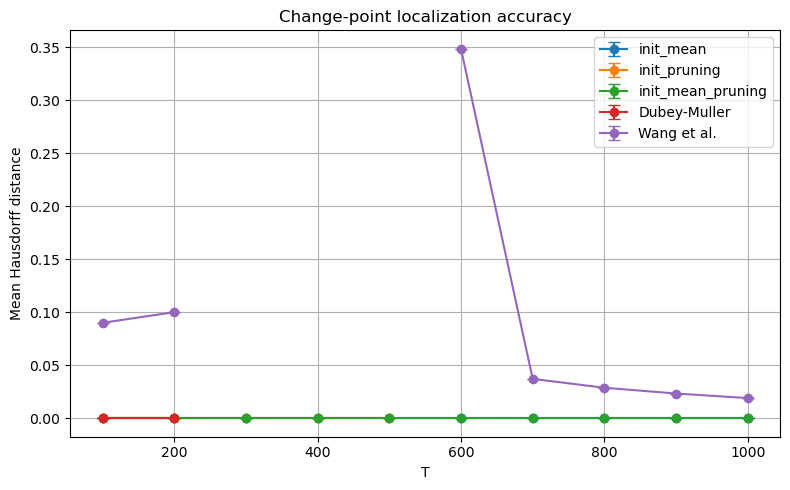

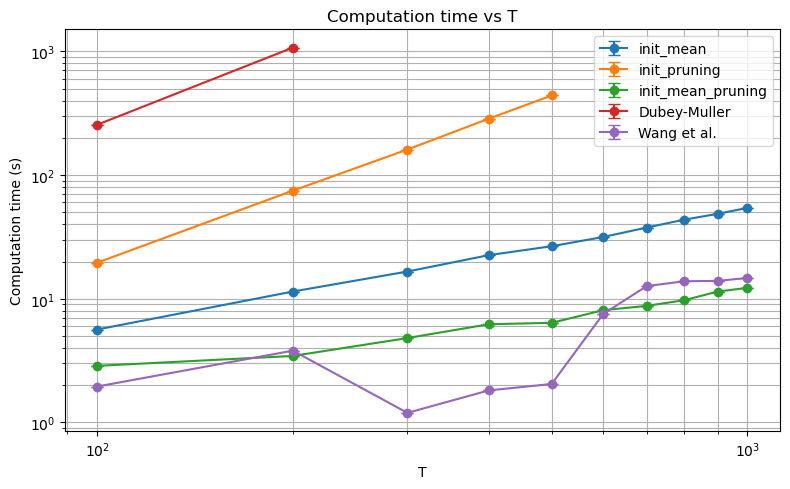

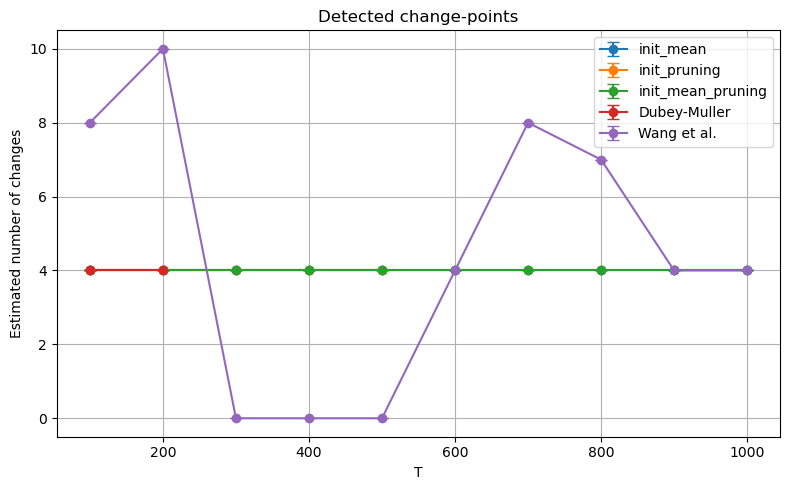

In [29]:
# -------------------------
# Example usage
# -------------------------

# List of time series lengths to test
list_T = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Number of Fréchet means for init_mean methods
nb_mean = 30

# Number of change points
n_changes = 4

# Pruning parameters
zeta = 0.2
gamma_2 = 4

# Number of repetitions for averaging
q = 1

# Number of nodes in the graphs
n_nodes = 20

# Small epsilon to ensure SPD
epsilon = 0.1

# Run the simulation
mean_hausdorff, mean_times, mean_nb_changes = run_simulation_graphs(
    list_T=list_T,
    nb_mean=nb_mean,
    n_changes=n_changes,
    zeta=zeta,
    gamma_2=gamma_2,
    q=q,
    n_nodes=n_nodes,
    epsilon=epsilon
)


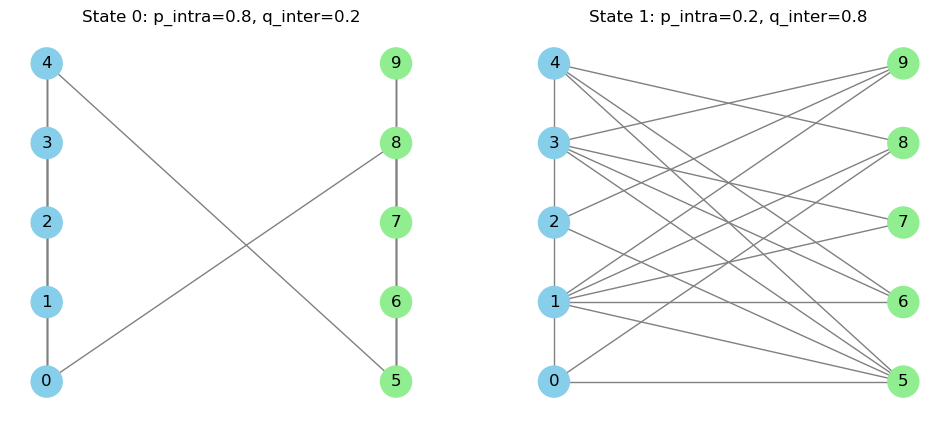

In [332]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Parameters
n_nodes = 10
n_blocks = 2
p_list = [0.8, 0.2]
q_list = [0.2, 0.8]

# Define block sizes
sizes = [n_nodes // n_blocks] * n_blocks
if sum(sizes) < n_nodes:
    sizes[-1] += n_nodes - sum(sizes)

# Define fixed positions: one community on the left, one on the right
pos = {}
for i in range(sizes[0]):
    pos[i] = (0, i)  # Community 0 on the left
for i in range(sizes[1]):
    pos[i + sizes[0]] = (1, i)  # Community 1 on the right

plt.figure(figsize=(12, 5))

for state in [0, 1]:
    p_intra = p_list[state]
    q_inter = q_list[state]
    
    # Probability matrix
    probs = np.full((n_blocks, n_blocks), q_inter)
    np.fill_diagonal(probs, p_intra)
    
    # Generate SBM graph
    G = nx.stochastic_block_model(sizes, probs, seed=42)
    
    plt.subplot(1, 2, state + 1)
    nx.draw(G, pos, with_labels=True,
            node_color=['skyblue']*sizes[0] + ['lightgreen']*sizes[1],
            node_size=500, edge_color='gray')
    plt.title(f'State {state}: p_intra={p_intra}, q_inter={q_inter}')

plt.show()
